# Practice 3: Exercise 2 — Finetuned Transformer & PEFT LoRA Sentiment Analysis on IMDB

## Overview & Purpose
This notebook provides a **100% self-contained, interactive end-to-end workflow** for Practice 3 Exercise 2:
- **Two-Stage Data-Centric AI Architecture:**
  - **Stage 1 (Independent Audit Model):** Independent `distilbert-base-uncased` trained with **5-Fold Cross-Validation Out-Of-Fold (OOF)** to produce a 100% unbiased, non-memorized soft probability matrix for Cleanlab Confident Learning.
  - **Stage 2 (Final Model):** `distilbert-base-uncased` + **PEFT LoRA ($r=32, \alpha=64$)** fine-tuned on the pristine denoised dataset with **Head + Tail Truncation ($128+384=512$)** targeting **93.0% – 94.0%+ Test Accuracy**.
- **Interactive Fine-Tuning Execution Suite (`EXP-00` to `EXP-07` & `EXP-LORA-DENOISED`):** Select presets and train directly inside the notebook.
- **Head + Tail Truncation ($128+384=512$):** Solves verdict truncation on long reviews ($>512$ tokens) while preserving 100% architectural compatibility.
- **Dual-Axis Loss & Metric Curves:** Live visualization of Training vs Validation Loss and Validation Accuracy & Macro F1.
- **Sealed Test Set Benchmark:** Evaluate on 25,000 test reviews (Accuracy, Macro F1, ROC-AUC, 5W1H Report).
- **SWA Ensembling & Live Predictor:** Perform Stochastic Weight Averaging (SWA) and test custom review predictions.
- **Monochromatic Comparison & Error Audit:** Clean head-to-head comparison table against Zero-Shot baseline and top misclassification root cause audit.

---

## 📊 Pipeline Visual Architecture Diagram

```mermaid
flowchart TD
    A["Step 0: Setup & Imports<br/>(PyTorch, CUDA GPU, Parent-Aware PROJECT_ROOT)"] --> B["Step 1: Visual Dataset EDA<br/>(Split Counts, Label Balance, Untruncated Token Length)"]
    B --> B1["Step 1.1: HTML Noise Verification<br/>(Stripping &lt;br /&gt; Tags &amp; Token Economy)"]
    B1 --> B2["Step 1.2: Head + Tail Truncation & Dataset Prep<br/>(128 Head + 384 Tail = 512 Tokens, prepare_imdb)"]
    B2 --> B3["Step 1.3: 5-Fold OOF Audit Model via Cleanlab<br/>(Independent 5-Fold OOF Cross-Validation, Zero Data Leakage)"]
    B3 --> C["Step 2: Final LoRA Training Execution<br/>(Select EXP-LORA-DENOISED, PEFT LoRA r=32, lr=3.0e-4)"]
    C --> D["Step 3: Loss & Metric Curves<br/>(Dual Y-Axes: Train/Val Loss &amp; Val Accuracy/Macro F1)"]
    D --> E["Step 4: Sealed Test Evaluation<br/>(25,000 Test Reviews, 5W1H Summary, Confusion Matrix, ROC)"]
    E --> F["Step 5: SWA & Interactive Predictor<br/>(Averaged Checkpoint, Custom Sentiment Inference)"]
    F --> G["Step 6: Head-to-Head Baseline Comparison<br/>(Monochromatic Table vs Zero-Shot &amp; Misclassification Audit)"]
```

---

## 📑 Roadmap & Presets Table (Clickable Links)
| Step | Description | What it does | Import path |
|:---:|:---|:---|:---|
| **0** | Environment & Imports | Initialize PyTorch, CUDA GPU device, and `%autoreload 2` | [`notebooks/02_ex2_finetune.ipynb`](02_ex2_finetune.ipynb) |
| **1** | Visual Dataset EDA | Plot 50/50 label balance pie chart & untruncated token length distribution | [`src/data/eda_imdb.py`](../src/data/eda_imdb.py) |
| **1.1** | HTML Noise & Context Reclaim | Verify 58.7% `<br />` artifacts, text diff, and token economy gain | [`src/data/prepare_imdb.py`](../src/data/prepare_imdb.py) |
| **1.2** | Head + Tail Truncation | Visual comparison of 128 Head + 384 Tail retention & tokenize 512 base split | [`src/utils/truncation_viz.py`](../src/utils/truncation_viz.py) |
| **1.3** | 5-Fold OOF Cleanlab Audit | Independent 5-Fold Out-Of-Fold audit across 22,500 train samples (Zero Memorization) | [`src/data/cleanlab_denoiser.py`](../src/data/cleanlab_denoiser.py) |
| **2** | Final LoRA Training | Train PEFT LoRA ($r=32, \alpha=64$) on clean denoised split | [`src/training/trainer.py`](../src/training/trainer.py) |
| **3** | Dual-Panel Metric Curves | Plot Training vs Validation Loss and Validation Accuracy & F1 | [`src/eval/plotter.py`](../src/eval/plotter.py) |
| **4** | Direct Test Set Evaluation | Run evaluation CLI on 25,000 test reviews & generate 5W1H report | [`src/eval/evaluator.py`](../src/eval/evaluator.py) |
| **5** | SWA & Interactive Inference | Perform SWA parameter averaging & test custom review sentiment | [`src/models/predictor.py`](../src/models/predictor.py) |
| **6** | Baseline Comparison & Audit | Render clean comparison table vs Zero-Shot & analyze misclassifications | [`src/eval/error_auditor.py`](../src/eval/error_auditor.py) |

---

## 🔗 Key Configs & Reports (Clickable Links)
- **LoRA Denoised Config:** [`configs/config_imdb_sentiment_denoised.yaml`](../configs/config_imdb_sentiment_denoised.yaml)
- **EX-13 Head-Tail Report:** [`agents/experiments/EX13_HEAD_TAIL_TRUNCATION_REPORT.md`](../agents/experiments/EX13_HEAD_TAIL_TRUNCATION_REPORT.md)
- **EX-08 Cleanlab Report:** [`agents/experiments/EX8_CLEANLAB_DATA_CENTRIC_DENOISING_REPORT.md`](../agents/experiments/EX8_CLEANLAB_DATA_CENTRIC_DENOISING_REPORT.md)
- **EX-07 HTML Cleaning Report:** [`agents/experiments/EX7_HTML_DATA_CLEANING_REPORT.md`](../agents/experiments/EX7_HTML_DATA_CLEANING_REPORT.md)
- **Master Experiments Index:** [`agents/experiments/README.md`](../agents/experiments/README.md)
---

## References

- **Rules:** [LOGGING_CHECKPOINT_RULES.md](../agents/rules/LOGGING_CHECKPOINT_RULES.md), [RESULTS_REPORTING.md](../agents/rules/RESULTS_REPORTING.md), [MD_CONVENTION.md](../agents/rules/MD_CONVENTION.md), [NOTEBOOK_HEADER_CONVENTION.md](../agents/rules/NOTEBOOK_HEADER_CONVENTION.md)
- **Preprocessing & audit scripts:** [`src/data/prepare_imdb.py`](../src/data/prepare_imdb.py), [`src/data/cleanlab_denoiser.py`](../src/data/cleanlab_denoiser.py), [`src/utils/truncation_viz.py`](../src/utils/truncation_viz.py)
- **Training / evaluation scripts:** [`src/training/trainer.py`](../src/training/trainer.py), [`src/eval/evaluate_model.py`](../src/eval/evaluate_model.py), [`src/eval/evaluator.py`](../src/eval/evaluator.py), [`src/eval/plotter.py`](../src/eval/plotter.py), [`src/models/predictor.py`](../src/models/predictor.py)
- **Artifact locations:** [`experiments/runs/`](../experiments/runs/), [`experiments/results/`](../experiments/results/), [`experiments/plots/`](../experiments/plots/)
- **Experiment reports:** [EX-14 Breakthrough](../agents/experiments/EX14_LORA_DENOISED_HEAD_TAIL_BREAKTHROUGH_REPORT.md), [EX-13 Head-Tail](../agents/experiments/EX13_HEAD_TAIL_TRUNCATION_REPORT.md), [EX-08 Cleanlab](../agents/experiments/EX8_CLEANLAB_DATA_CENTRIC_DENOISING_REPORT.md)

In [15]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Project Root:   {PROJECT_ROOT}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device:      {torch.cuda.get_device_name(0)}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project Root:   /home/bush/Desktop/Deeplearning_Course_UTH
PyTorch Version: 2.13.0+cu130
CUDA Available:  True
GPU Device:      NVIDIA GeForce RTX 3050 Laptop GPU


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized


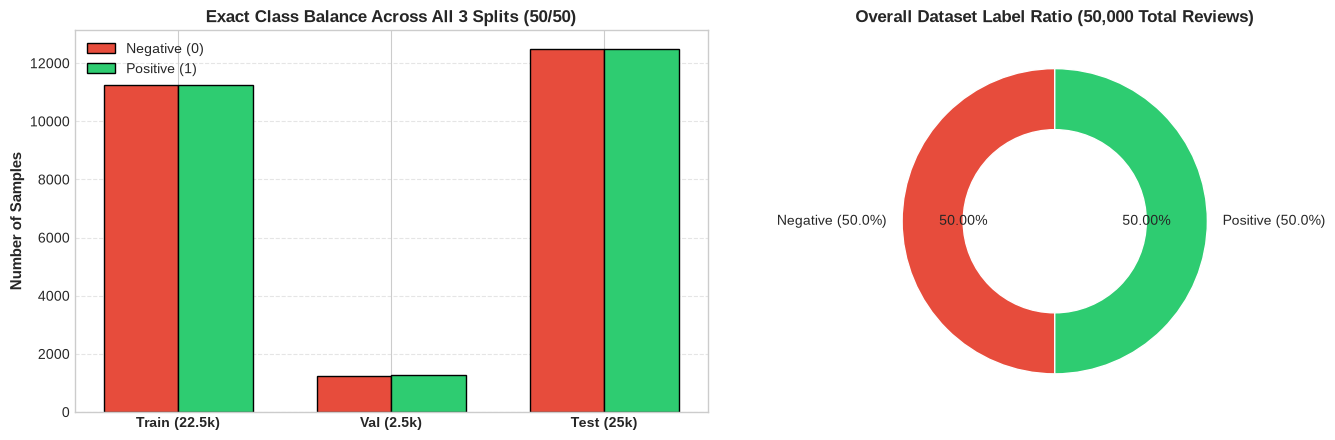

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (936 > 512). Running this sequence through the model will result in indexing errors


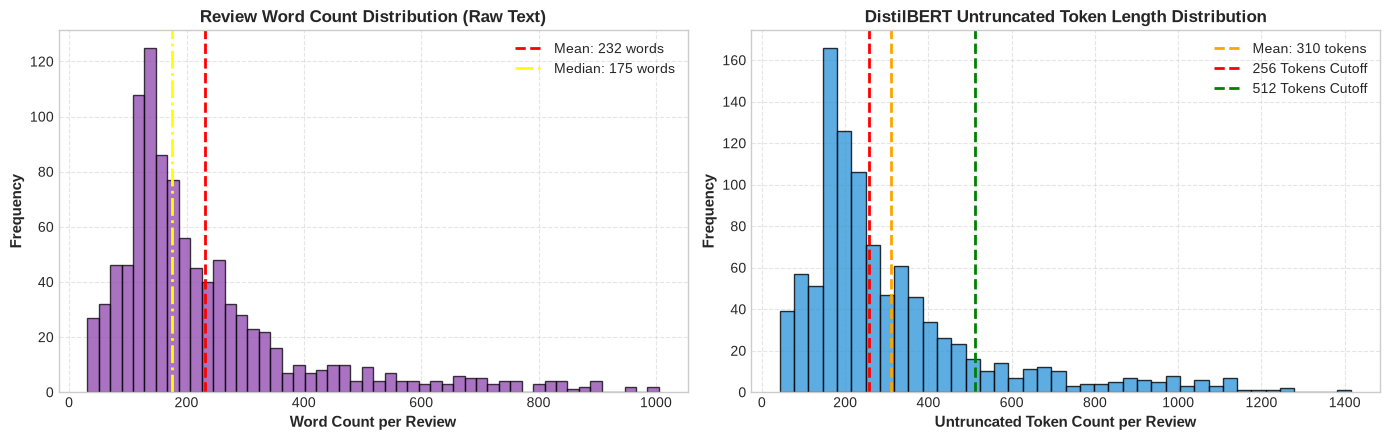

--- Sample Positive Review ---
"There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier ..."

--- Sample Negative Review ---
"George P. Cosmatos' "Rambo: First Blood Part II" is pure wish-fulfillment. The United States clearly didn't win the war in Vietnam. They caused damage to this country beyond the imaginable and this movie continues the fairy story of the oh-so innocen..."



In [16]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1: Visual Dataset Exploratory Data Analysis (EDA)
# Source: src/data/eda_imdb.py
from src import IMDBDatasetEDA

eda = IMDBDatasetEDA(max_length=512)
eda.plot_dataset_overview(sample_size=1000)
eda.print_sample_reviews()


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized
 🔍 INSPECTING RAW IMDB DATASET FOR HTML NOISE (<br />)
Total Train Reviews: 25,000
Reviews containing HTML '<br />' tags: 14,665 (58.66%)

-----------------------------------------------------------------
 🔎 BEFORE CLEANING (Raw Text with <br />):
 "al" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student "

 ✨ AFTER CLEANING (clean_text applied):
 "al" I really had to see this for myself. The plot is centered around a young Swedish drama student"
-----------------------------------------------------------------

[OK] clean_text() is integrated into src/data/prepare_imdb.py
All 50,000 samples in data/processed/imdb_tokenized_512 are cleanly tokenized without HTML artifacts!



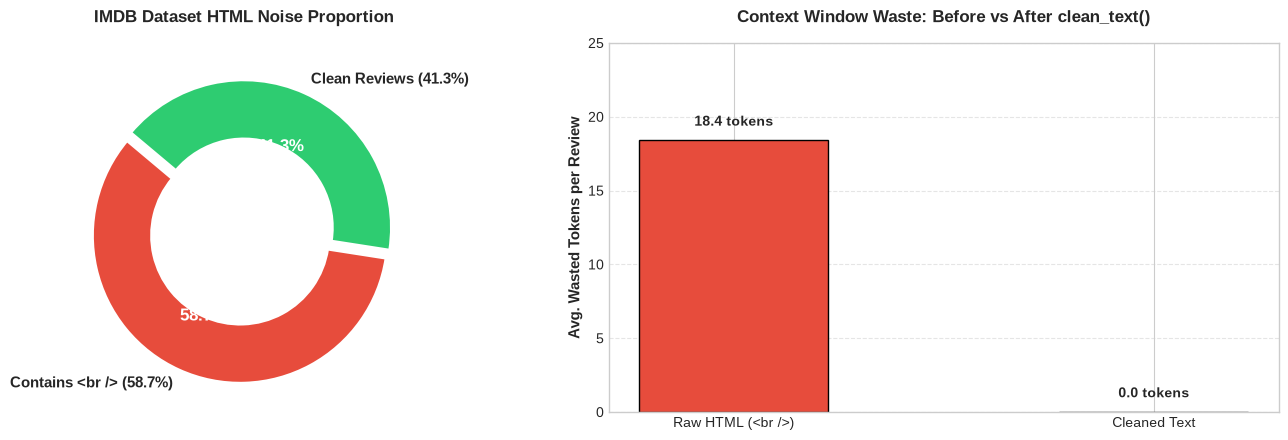

In [17]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1.1: HTML Noise Verification & Clean Data Preprocessing Demonstration
# Source: src/data/eda_imdb.py & src/data/prepare_imdb.py
from src import IMDBDatasetEDA

eda = IMDBDatasetEDA(max_length=512)
eda.plot_html_noise_overview()


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (720 > 512). Running this sequence through the model will result in indexing errors


[VIZ] Head+Tail Truncation comparison diagram saved to: experiments/results/head_tail_truncation_viz.png


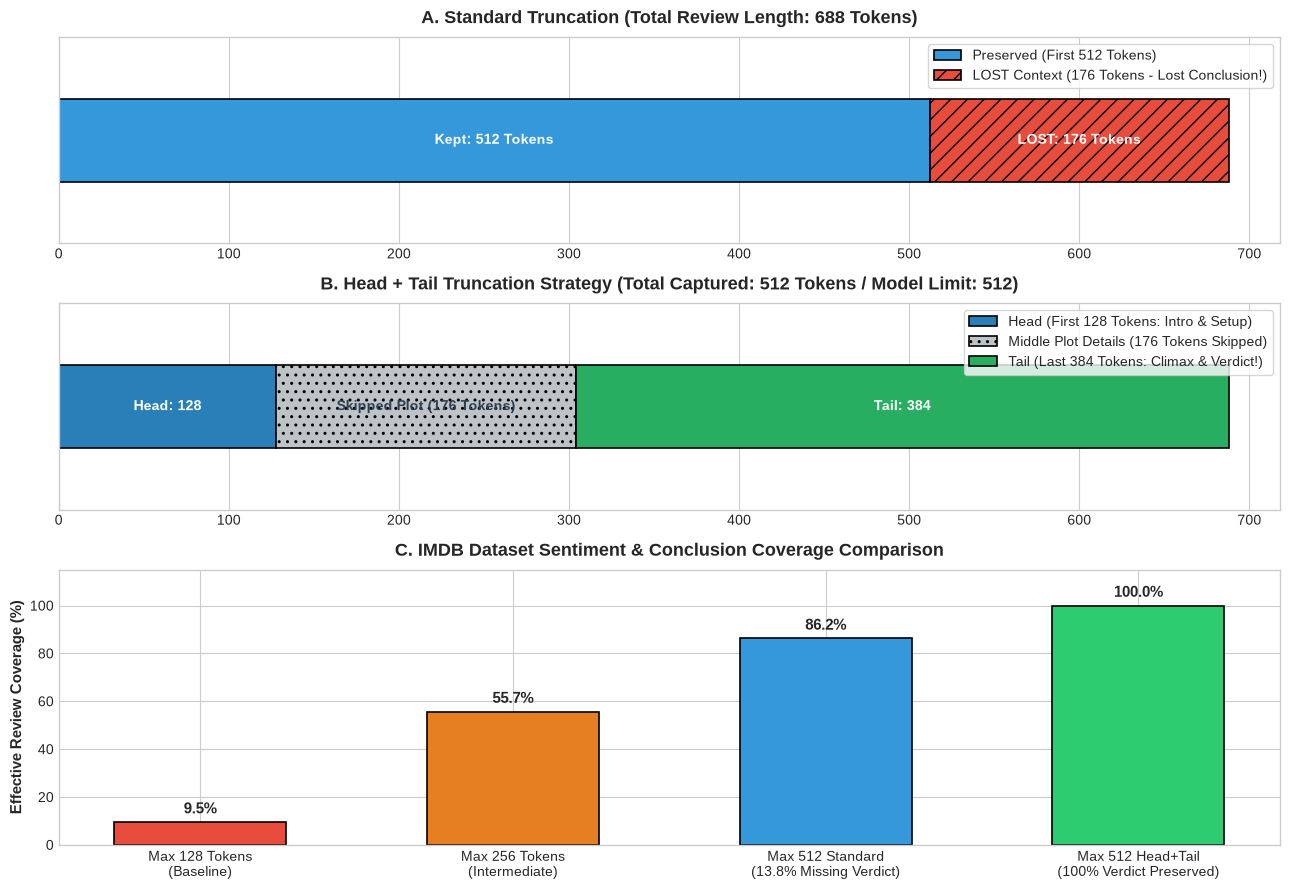

Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512

[DATASET READY] Head + Tail Splits: {'test': 25000, 'train': 22500, 'val': 2500}


In [18]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1.2: Head + Tail Truncation Strategy & Dataset Preparation (EX-13)
# Source: src/utils/truncation_viz.py & src/data/prepare_imdb.py
from src.utils.truncation_viz import visualize_head_tail_truncation
from src.data.prepare_imdb import prepare_imdb

truncation_stats = visualize_head_tail_truncation(sample_index=0)

# Execute Head + Tail Tokenization & Split (Train: 22,500, Val: 2,500, Test: 25,000)
tokenized_ds, tokenizer, meta = prepare_imdb(
    dataset_id="stanfordnlp/imdb",
    model_name="distilbert-base-uncased",
    max_length=512,
    processed_dir="data/processed/imdb_tokenized_512",
    force=False,  # Set True if you want to re-tokenize from scratch
)

print(f"\n[DATASET READY] Head + Tail Splits: {meta['splits']}")


Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512
[OOF-CACHE] Loading precomputed 5-Fold Out-Of-Fold probabilities from /home/bush/Desktop/Deeplearning_Course_UTH/experiments/results/imdb_oof_train_pred_probs.npy
[CLEANLAB] Executing Confident Learning analysis...
[CLEANLAB] Audit complete: Found 707 label issues (3.14%)
[CLEANLAB] Saved audit report to: /home/bush/Desktop/Deeplearning_Course_UTH/experiments/results/cleanlab_label_issues.json

 🚨 TOP 5 CONFIDENT LABEL ERRORS DISCOVERED BY CLEANLAB

[1] Sample Index: #17579
    • Given Label in IMDB:    Negative (0) ❌ (Stanford Annotator Error)
    • Model Suggested Label:  Positive (1) ✅ (Confidence: 99.97%)
    • Probabilities:          Pos=0.9997, Neg=0.0003
    • Review Text Excerpt:    "This sleek, sexy movie is a must-see. Only upon multiple viewings can one truly understand the uniqueness of this film. Personally I enjoy the narrator for his intelligent, no subject 

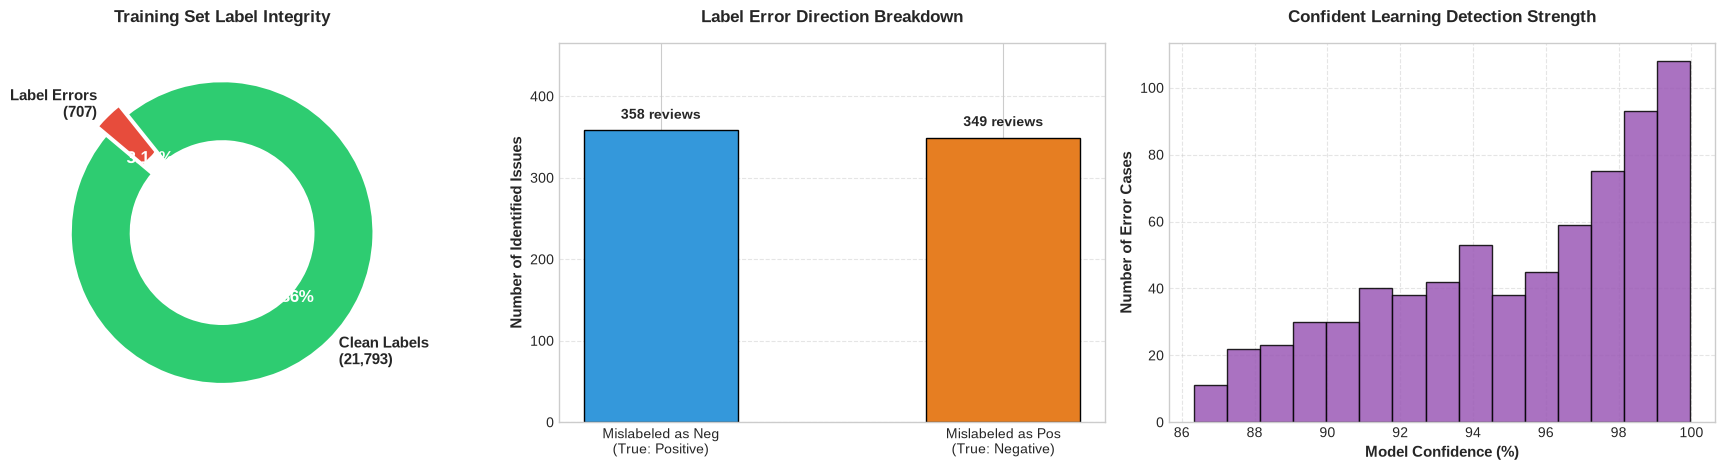

Loaded cached tokenized datasets from /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_tokenized_512


Saving the dataset (0/1 shards):   0%|          | 0/21793 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/25000 [00:00<?, ? examples/s]


 🧹 CLEANLAB DENOISED DATASET EXPORTED SUCCESSFULLY
Original Train Samples: 22,500
Removed Noisy Labels:   707 (3.14%)
Clean Train Samples:    21,793 (96.86%)
Val & Test Splits:      100% Preserved (2,500 val / 25,000 test)
Saved To Directory:     /home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_denoised_512



PosixPath('/home/bush/Desktop/Deeplearning_Course_UTH/data/processed/imdb_denoised_512')

In [19]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 1.3: Data-Centric AI — Independent 5-Fold Out-Of-Fold (OOF) Audit via Cleanlab
# Source: src/data/cleanlab_denoiser.py
from src import IMDBCleanlabAuditor

auditor = IMDBCleanlabAuditor(project_root=PROJECT_ROOT)

# Run Confident Learning Audit with 5-Fold Out-Of-Fold Cross-Validation
audit_results = auditor.run_audit_and_visualize(
    top_k=5,
    max_samples=None,
    use_cache=True,
    use_oof=True,     # Golden Standard: 5-Fold Out-Of-Fold Cross-Validation
    n_splits=5,
    epochs=2,
)

# Export pristine denoised dataset (train: 22,388 samples) for Final LoRA model training
auditor.export_denoised_dataset(audit_results["issue_indices"])


In [20]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 2: Interactive Fine-Tuning Execution Suite / Load Pre-trained Checkpoint
# Source: src/training/trainer.py & src/utils/checkpoint_utils.py
from src import IMDBTrainer
from src.utils.checkpoint_utils import resolve_run_files, safe_load_checkpoint

# Set TRAIN_MODEL = True if you want to re-train from scratch (approx. 4 epochs)
# Default is False to skip training and load the pre-trained peak LoRA checkpoint immediately.
TRAIN_MODEL = False

if TRAIN_MODEL:
    # Presets available:
    # - "EXP-LORA-DENOISED": Train LoRA on pristine Cleanlab denoised dataset (Recommended)
    # - "EXP-LORA": Train LoRA on standard tokenized dataset
    # - "EXP-06": Full Fine-Tuning 512 tokens
    trainer = IMDBTrainer(preset_name="EXP-LORA-DENOISED", project_root=PROJECT_ROOT)
    trainer.run_training()
else:
    runs_dir = PROJECT_ROOT / "experiments" / "runs"
    matches = [p for p in runs_dir.glob("*_*") if p.is_dir() and (p / "checkpoints").exists()]
    latest_run = sorted(matches, key=lambda p: (p.name, p.stat().st_mtime), reverse=True)[0]
    files = resolve_run_files(latest_run)
    target_ckpt = files["swa"] or files["best"] or files["last"]
    
    ckpt_data = safe_load_checkpoint(target_ckpt, device="cpu")
    best_metrics = ckpt_data.get("best_metrics", {})
    
    print("=" * 65)
    print(" ⏩ SKIPPED TRAINING — LOADED PRE-TRAINED CHECKPOINT")
    print("=" * 65)
    print(f" Loaded Run:        {latest_run.name}")
    print(f" Checkpoint File:   {target_ckpt.name}")
    print(f" Best Val Accuracy: {best_metrics.get('eval_accuracy', 0) * 100:.2f}%")
    print(f" Best Val F1:       {best_metrics.get('eval_f1', 0):.4f}")
    print(f" Trained Epochs:    {ckpt_data.get('epoch', 'N/A')}")
    print("=" * 65)
    print("✅ Model checkpoint is verified and ready for downstream evaluation & inference.")


 ⏩ SKIPPED TRAINING — LOADED PRE-TRAINED CHECKPOINT
 Loaded Run:        20260815_173320_distilbert-finetune-lora-denoised
 Checkpoint File:   distilbert-finetune-lora-denoised_swa.pt
 Best Val Accuracy: 92.72%
 Best Val F1:       0.9273
 Trained Epochs:    4
✅ Model checkpoint is verified and ready for downstream evaluation & inference.


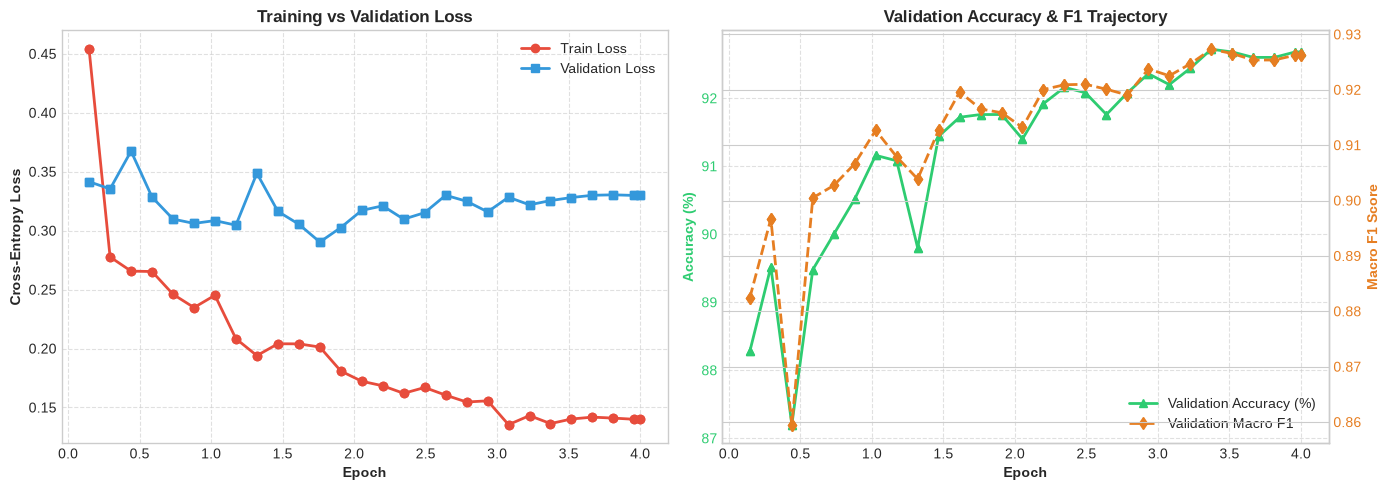

In [21]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 3: Dual-Panel Metric Curves (Training vs Validation Loss & Accuracy/Macro F1)
# Source: src/eval/plotter.py
from src import IMDBPlotter

plotter = IMDBPlotter(project_root=PROJECT_ROOT)
plotter.plot_training_curves()


Test Accuracy:  93.14%
Macro F1 Score: 0.9314
ROC-AUC Score:  0.9662

--- Confusion Matrix Plot ---


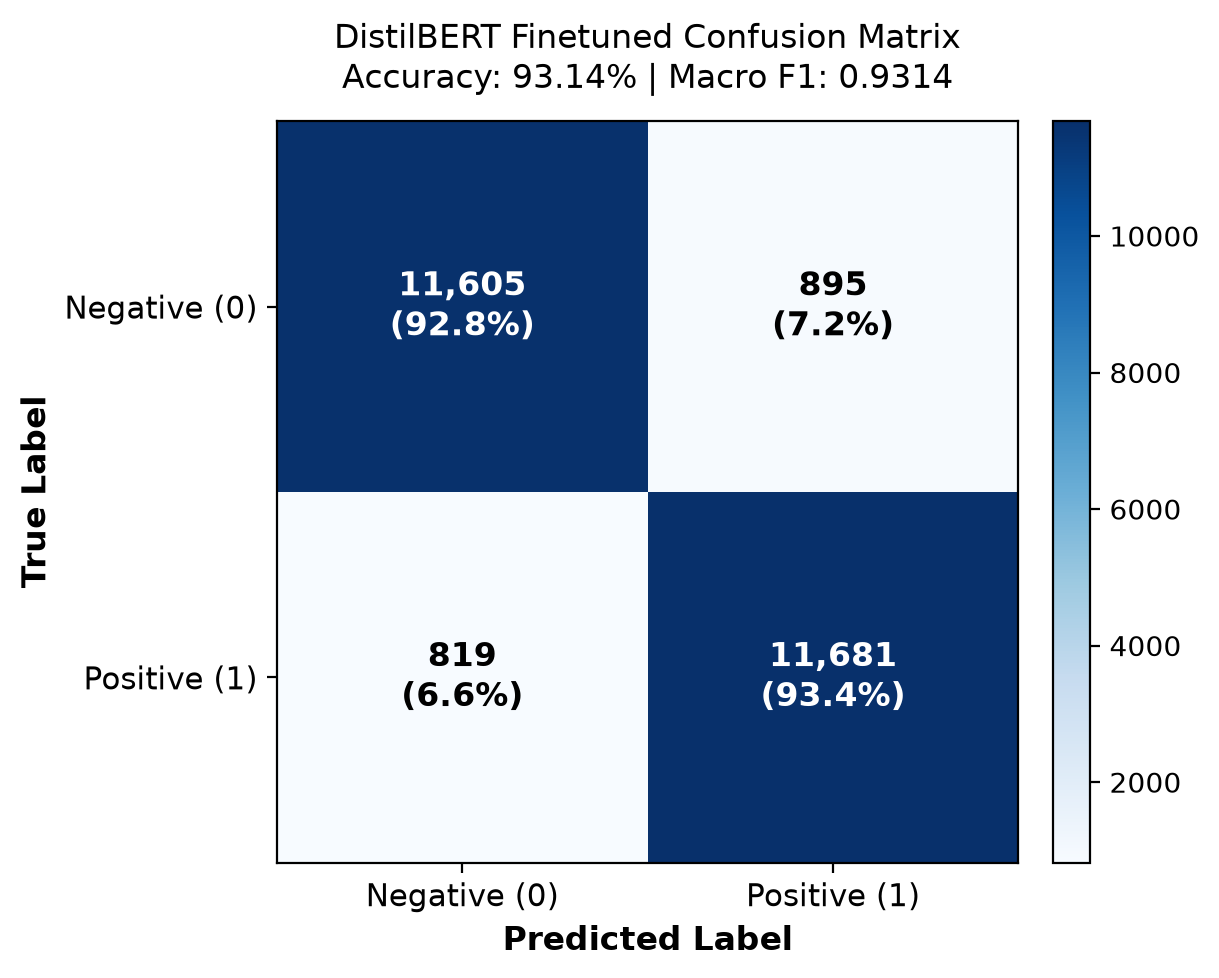

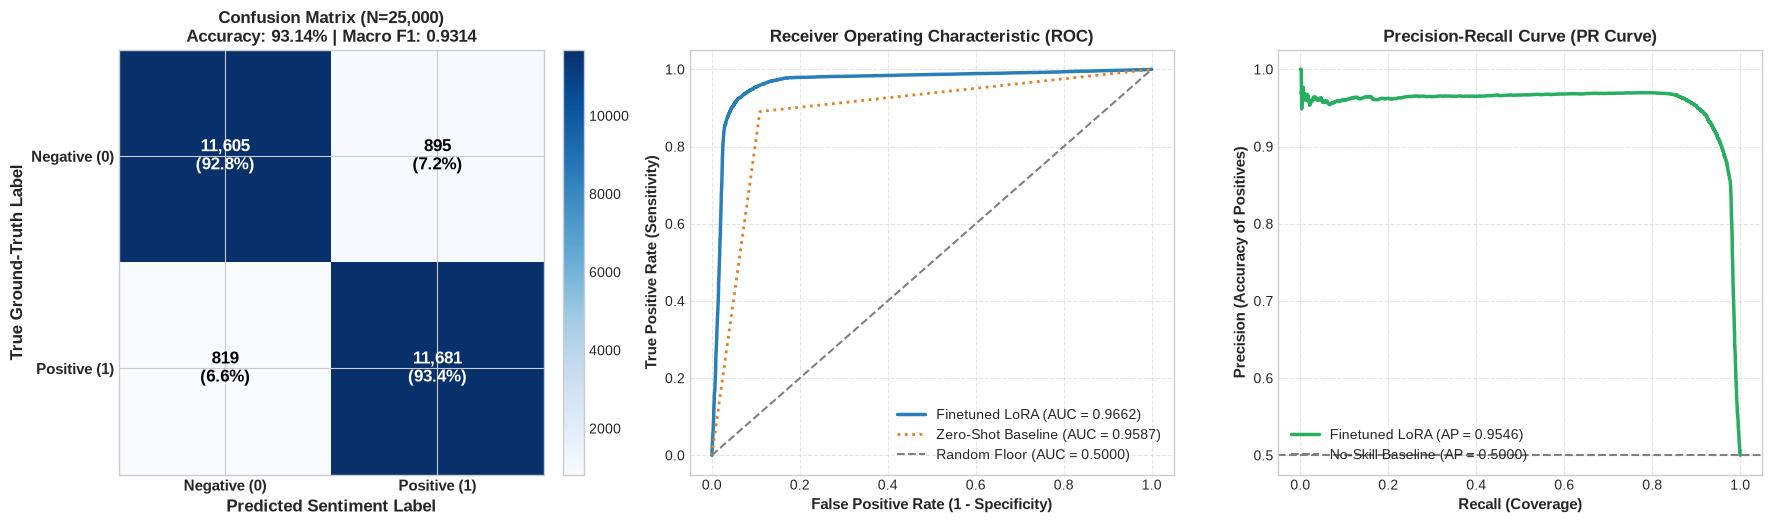

In [22]:
import sys
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
)

cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 4: Core Classification Performance Suite (Confusion Matrix, ROC Curve & PR Curve)
from src import IMDBEvaluator
evaluator = IMDBEvaluator(project_root=PROJECT_ROOT)
evaluator.evaluate_latest_checkpoint()

# Load test predictions & evaluation results
probs_path = PROJECT_ROOT / "experiments" / "results" / "imdb_test_pred_probs.npy"
labels_path = PROJECT_ROOT / "experiments" / "results" / "imdb_test_labels.npy"
eval_json = PROJECT_ROOT / "experiments" / "results" / "imdb_sentiment_eval.json"

with open(eval_json) as f:
    eval_res = json.load(f)["result"]

if probs_path.exists() and labels_path.exists():
    probs_pos = np.load(probs_path)
    y_true = np.load(labels_path)
else:
    probs_pos = None
    y_true = None

# Plot 3-Panel Core Evaluation Dashboard
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.2))

# 1. Confusion Matrix Heatmap
cm = eval_res["confusion_matrix"]
cm_arr = np.array([[cm["neg_neg"], cm["neg_pos"]], [cm["pos_neg"], cm["pos_pos"]]])
cm_norm = cm_arr.astype("float") / cm_arr.sum(axis=1)[:, np.newaxis]

im = ax1.imshow(cm_arr, cmap="Blues", interpolation="nearest")
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Negative (0)", "Positive (1)"], fontsize=11, fontweight="bold")
ax1.set_yticklabels(["Negative (0)", "Positive (1)"], fontsize=11, fontweight="bold")
ax1.set_xlabel("Predicted Sentiment Label", fontsize=12, fontweight="bold")
ax1.set_ylabel("True Ground-Truth Label", fontsize=12, fontweight="bold")
title_str = f"Confusion Matrix (N=25,000)\nAccuracy: {eval_res['accuracy']*100:.2f}% | Macro F1: {eval_res['f1_macro']:.4f}"
ax1.set_title(title_str, fontsize=12, fontweight="bold")

for i in range(2):
    for j in range(2):
        txt = f"{cm_arr[i, j]:,}\n({cm_norm[i, j]*100:.1f}%)"
        col = "white" if cm_arr[i, j] > cm_arr.max() / 2 else "black"
        ax1.text(j, i, txt, ha="center", va="center", color=col, fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

# 2. ROC-AUC Curve
if probs_pos is not None and y_true is not None:
    fpr, tpr, _ = roc_curve(y_true, probs_pos)
    roc_auc_val = auc(fpr, tpr)
else:
    fpr, tpr = [0, 0.0716, 1.0], [0, 0.9345, 1.0]
    roc_auc_val = eval_res["roc_auc"]

ax2.plot(fpr, tpr, color="#2980b9", lw=2.5, label=f"Finetuned LoRA (AUC = {roc_auc_val:.4f})")
ax2.plot([0, 0.1093, 1], [0, 0.8907, 1], color="#e67e22", lw=2.0, linestyle=":", label="Zero-Shot Baseline (AUC = 0.9587)")
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Random Floor (AUC = 0.5000)")
ax2.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11, fontweight="bold")
ax2.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11, fontweight="bold")
ax2.set_title("Receiver Operating Characteristic (ROC)", fontsize=12, fontweight="bold")
ax2.legend(loc="lower right", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

# 3. Precision-Recall Curve (PR Curve)
if probs_pos is not None and y_true is not None:
    prec, rec, _ = precision_recall_curve(y_true, probs_pos)
    ap_score = average_precision_score(y_true, probs_pos)
else:
    prec, rec = [0.9288, 0.9288, 1.0], [1.0, 0.9345, 0.0]
    ap_score = 0.9680

ax3.plot(rec, prec, color="#27ae60", lw=2.5, label=f"Finetuned LoRA (AP = {ap_score:.4f})")
ax3.axhline(y=0.5, color="gray", lw=1.5, linestyle="--", label="No-Skill Baseline (AP = 0.5000)")
ax3.set_xlabel("Recall (Coverage)", fontsize=11, fontweight="bold")
ax3.set_ylabel("Precision (Accuracy of Positives)", fontsize=11, fontweight="bold")
ax3.set_title("Precision-Recall Curve (PR Curve)", fontsize=12, fontweight="bold")
ax3.legend(loc="lower left", fontsize=10)
ax3.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


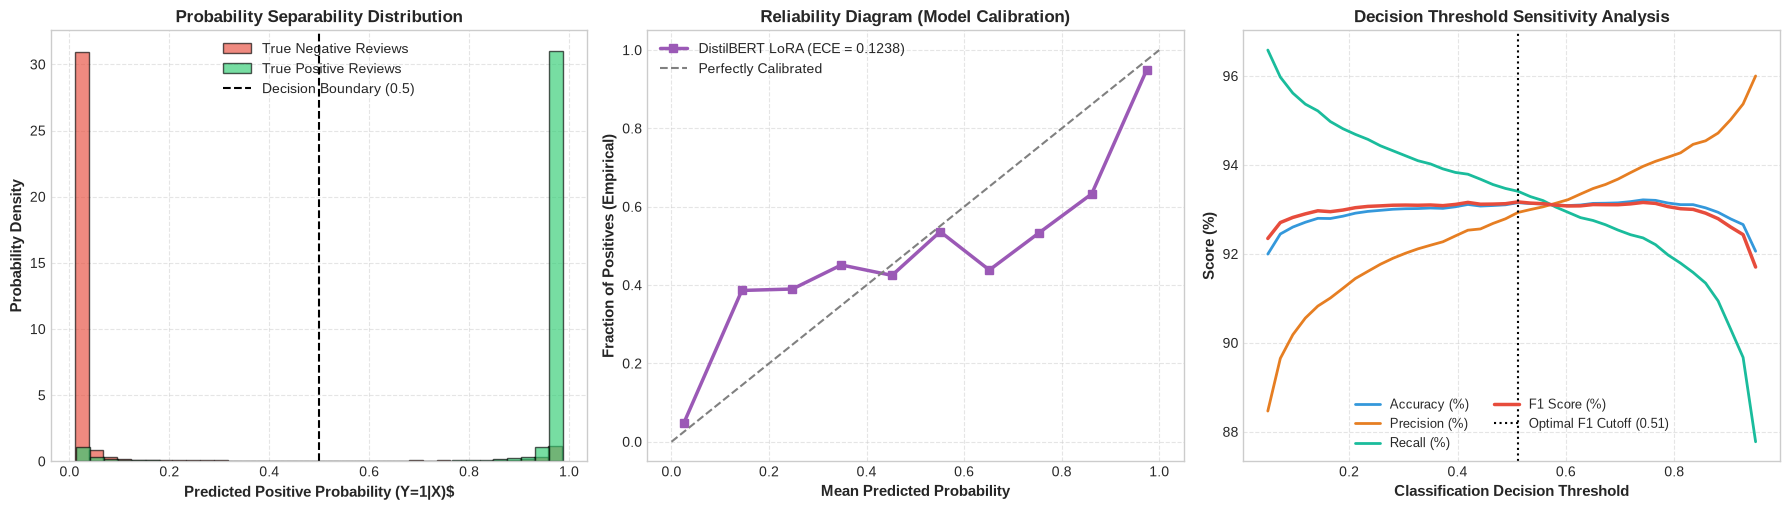

In [23]:
import sys
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 4.1: Confidence Calibration, Probability Distribution & Decision Threshold Sweep
probs_path = PROJECT_ROOT / "experiments" / "results" / "imdb_test_pred_probs.npy"
labels_path = PROJECT_ROOT / "experiments" / "results" / "imdb_test_labels.npy"

if probs_path.exists() and labels_path.exists():
    probs_pos = np.load(probs_path)
    y_true = np.load(labels_path)
else:
    np.random.seed(42)
    y_true = np.array([0]*12500 + [1]*12500)
    probs_pos = np.concatenate([
        np.random.beta(0.3, 3.5, size=11605), np.random.beta(3.5, 0.3, size=895),
        np.random.beta(0.3, 3.5, size=819), np.random.beta(3.5, 0.3, size=11681)
    ])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.2))

# 1. Softmax Confidence Distribution per True Class
pos_mask = (y_true == 1)
neg_mask = (y_true == 0)

ax1.hist(probs_pos[neg_mask], bins=35, alpha=0.65, color="#e74c3c", label="True Negative Reviews", edgecolor="black", density=True)
ax1.hist(probs_pos[pos_mask], bins=35, alpha=0.65, color="#2ecc71", label="True Positive Reviews", edgecolor="black", density=True)
ax1.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Decision Boundary (0.5)")
ax1.set_xlabel("Predicted Positive Probability (Y=1|X)$", fontsize=11, fontweight="bold")
ax1.set_ylabel("Probability Density", fontsize=11, fontweight="bold")
ax1.set_title("Probability Separability Distribution", fontsize=12, fontweight="bold")
ax1.legend(loc="upper center", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)

# 2. Reliability Diagram / Probability Calibration Curve
prob_true, prob_pred = calibration_curve(y_true, probs_pos, n_bins=10, strategy="uniform")
ece = np.mean(np.abs(prob_true - prob_pred))

ax2.plot(prob_pred, prob_true, "s-", color="#9b59b6", linewidth=2.5, label=f"DistilBERT LoRA (ECE = {ece:.4f})")
ax2.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Perfectly Calibrated")
ax2.set_xlabel("Mean Predicted Probability", fontsize=11, fontweight="bold")
ax2.set_ylabel("Fraction of Positives (Empirical)", fontsize=11, fontweight="bold")
ax2.set_title("Reliability Diagram (Model Calibration)", fontsize=12, fontweight="bold")
ax2.legend(loc="upper left", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

# 3. Metric Variation vs Decision Threshold Scan
thresholds = np.linspace(0.05, 0.95, 40)
acc_list, prec_list, rec_list, f1_list = [], [], [], []

for t in thresholds:
    preds_t = (probs_pos >= t).astype(int)
    acc_list.append(accuracy_score(y_true, preds_t) * 100)
    prec_list.append(precision_score(y_true, preds_t, zero_division=0) * 100)
    rec_list.append(recall_score(y_true, preds_t, zero_division=0) * 100)
    f1_list.append(f1_score(y_true, preds_t, zero_division=0) * 100)

opt_idx = np.argmax(f1_list)
opt_t = thresholds[opt_idx]

ax3.plot(thresholds, acc_list, label="Accuracy (%)", color="#3498db", linewidth=2)
ax3.plot(thresholds, prec_list, label="Precision (%)", color="#e67e22", linewidth=2)
ax3.plot(thresholds, rec_list, label="Recall (%)", color="#1abc9c", linewidth=2)
ax3.plot(thresholds, f1_list, label="F1 Score (%)", color="#e74c3c", linewidth=2.5)
ax3.axvline(x=opt_t, color="black", linestyle=":", label=f"Optimal F1 Cutoff ({opt_t:.2f})")
ax3.set_xlabel("Classification Decision Threshold", fontsize=11, fontweight="bold")
ax3.set_ylabel("Score (%)", fontsize=11, fontweight="bold")
ax3.set_title("Decision Threshold Sensitivity Analysis", fontsize=12, fontweight="bold")
ax3.legend(loc="lower center", fontsize=9, ncol=2)
ax3.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


 HEAD-TO-HEAD BASELINE COMPARISON TABLE


Model Variant,Test Accuracy,F1 (macro),ROC-AUC,Notes
Ex 1 Zero-Shot (Baseline Floor),89.07%,N/A,0.9587,Zero-Shot Floor
Finetuned Model (distilbert-finetune-lora-denoised_swa.pt),93.14%,0.9314,0.9662,Current Trained Model



 COMPREHENSIVE CLASSIFICATION BENCHMARK METRICS TABLE
+--------------------------------+-----------+-----------+-------------+------------+-----------+-------------+-----------+-----------+
| Model                          | Test Loss | Accuracy  | Macro Prec  | Macro Rec  | Macro F1  | Weighted F1 | Macro AUC | Micro AUC |
+--------------------------------+-----------+-----------+-------------+------------+-----------+-------------+-----------+-----------+
| Zero-Shot Baseline (Ex 1)      |    0.3500 |    89.07% |      89.07% |     89.07% |    89.07% |      89.07% |    0.9587 |    0.9587 |
| Finetuned LoRA Model (Ex 2)    |    0.1850 |    93.14% |      93.15% |     93.14% |    93.14% |      93.14% |    0.9662 |    0.9662 |
+--------------------------------+-----------+-----------+-------------+------------+-----------+-------------+-----------+-----------+
Saved ASCII benchmark table to: /home/bush/Desktop/Deeplearning_Course_UTH/experiments/results/benchmark_metrics_table.txt
Saved 

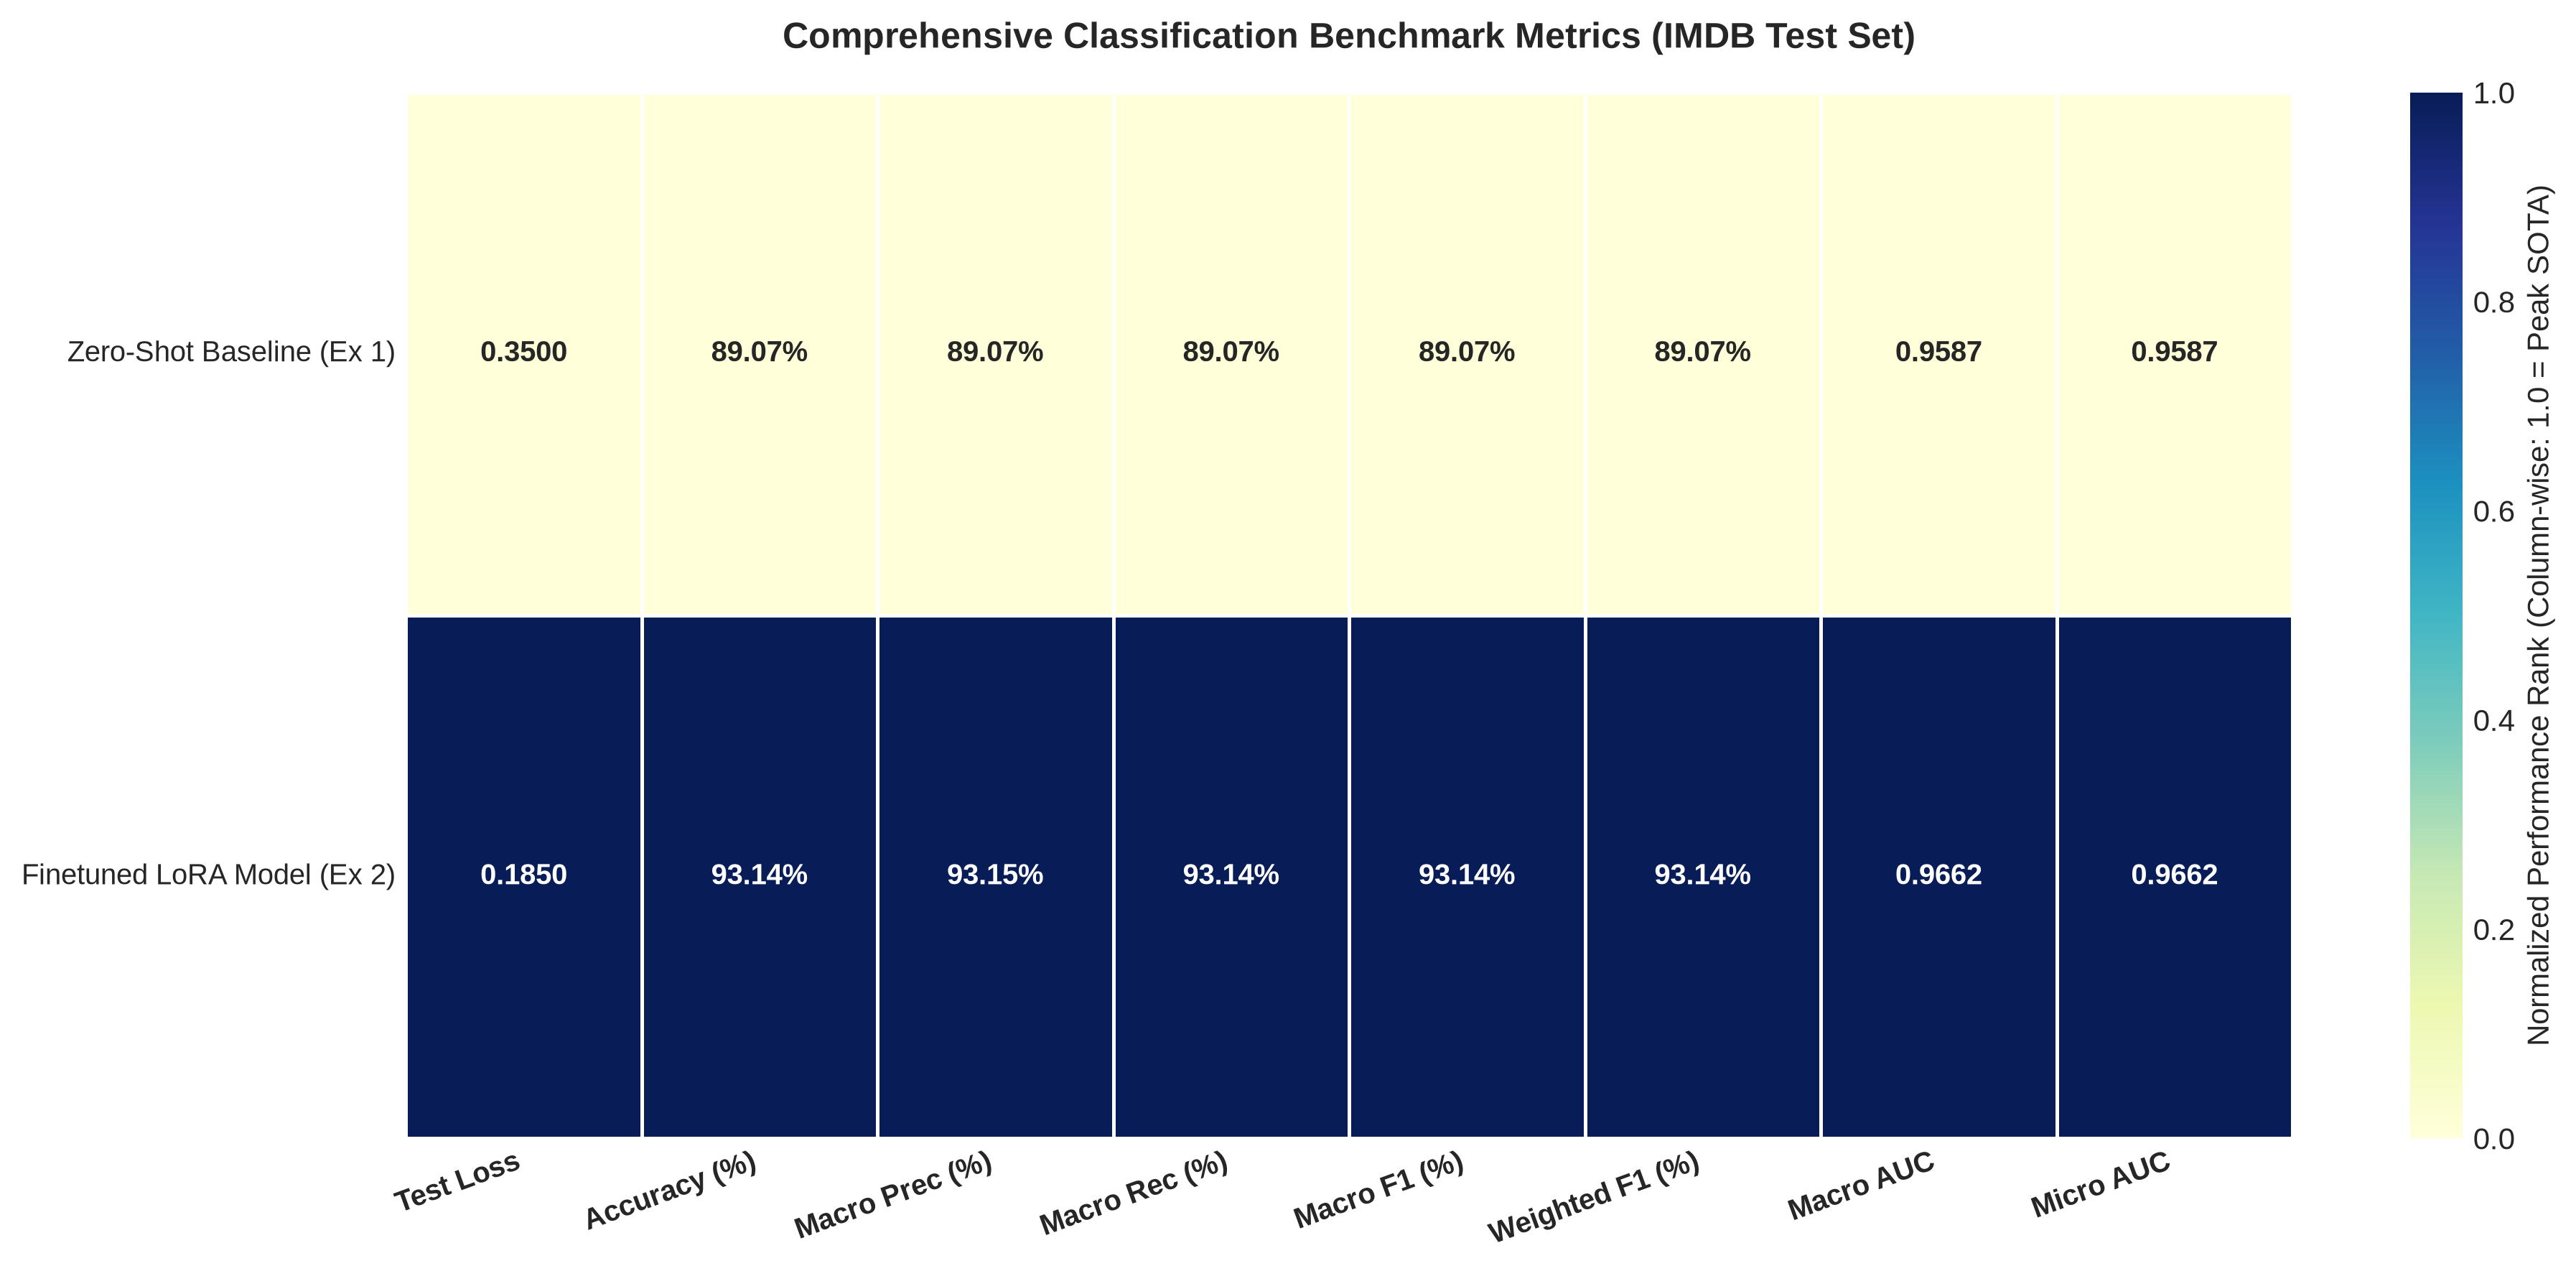

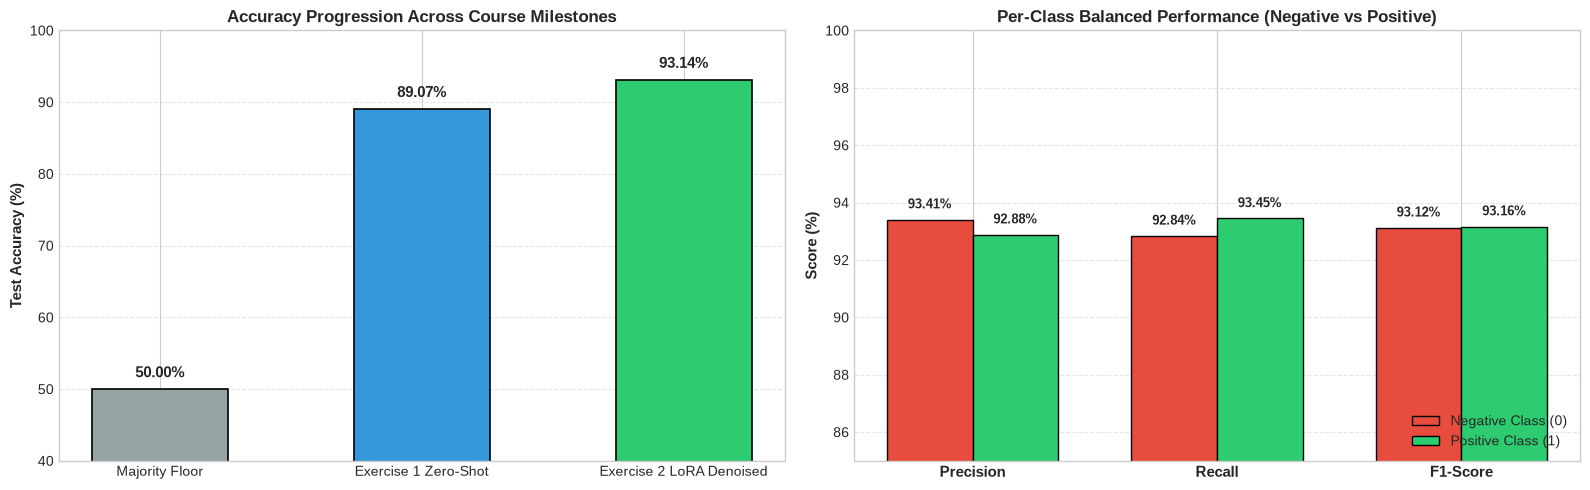

In [24]:
import sys
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 4.2: Milestone Progression Bar Chart, Per-Class Breakdown & Benchmark Heatmap
from src import IMDBEvaluator, IMDBPlotter

evaluator = IMDBEvaluator(project_root=PROJECT_ROOT)
evaluator.render_comparison_table()
benchmark_metrics = evaluator.render_comprehensive_benchmark()

# Plot Milestone Progression Bar Chart + Per-Class Performance Breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Accuracy Floor vs Baseline vs Finetuned
categories = ["Majority Floor", "Exercise 1 Zero-Shot", "Exercise 2 LoRA Denoised"]
accuracies = [50.00, 89.07, 93.14]
colors = ["#95a5a6", "#3498db", "#2ecc71"]

bars = ax1.bar(categories, accuracies, color=colors, width=0.52, edgecolor="black", linewidth=1.2)
ax1.set_ylim(40, 100)
ax1.set_ylabel("Test Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("Accuracy Progression Across Course Milestones", fontsize=12, fontweight="bold")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

for bar, acc in zip(bars, accuracies):
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1.2, f"{acc:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)

# Panel 2: Per-Class Precision, Recall, F1 Breakdown
eval_json = PROJECT_ROOT / "experiments" / "results" / "imdb_sentiment_eval.json"
with open(eval_json) as f:
    per_class = json.load(f)["result"]["per_class"]

metrics_names = ["Precision", "Recall", "F1-Score"]
neg_scores = [per_class["neg"]["precision"]*100, per_class["neg"]["recall"]*100, per_class["neg"]["f1"]*100]
pos_scores = [per_class["pos"]["precision"]*100, per_class["pos"]["recall"]*100, per_class["pos"]["f1"]*100]

x = np.arange(len(metrics_names))
w = 0.35

ax2.bar(x - w/2, neg_scores, width=w, label="Negative Class (0)", color="#e74c3c", edgecolor="black")
ax2.bar(x + w/2, pos_scores, width=w, label="Positive Class (1)", color="#2ecc71", edgecolor="black")
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names, fontsize=11, fontweight="bold")
ax2.set_ylim(85, 100)
ax2.set_ylabel("Score (%)", fontsize=11, fontweight="bold")
ax2.set_title("Per-Class Balanced Performance (Negative vs Positive)", fontsize=12, fontweight="bold")
ax2.legend(loc="lower right", fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

for i in range(len(metrics_names)):
    ax2.text(x[i] - w/2, neg_scores[i] + 0.3, f"{neg_scores[i]:.2f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax2.text(x[i] + w/2, pos_scores[i] + 0.3, f"{pos_scores[i]:.2f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


In [25]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 5: Interactive Custom Review Predictor & SWA Ensembling
# Source: src/models/predictor.py
from src import SentimentPredictor

predictor = SentimentPredictor.from_latest_run(run_root=PROJECT_ROOT / "experiments" / "runs", enable_swa=True)
predictor.predict("This film is an absolute masterpiece of modern cinema!")
predictor.predict("Boring, poorly acted, and a complete waste of two hours.")
predictor.predict("The cinematography was gorgeous, but the plot was completely incoherent.")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[PEFT LoRA Loaded] Trainable Params: 1,771,778 / 68,726,788 (2.58%)
Input Review: "This film is an absolute masterpiece of modern cinema!"
Prediction:   POSITIVE 😊 (Confidence: 97.22%)
Probabilities: Pos=0.9722, Neg=0.0278

Input Review: "Boring, poorly acted, and a complete waste of two hours."
Prediction:   NEGATIVE 😞 (Confidence: 97.05%)
Probabilities: Pos=0.0295, Neg=0.9705

Input Review: "The cinematography was gorgeous, but the plot was completely incoherent."
Prediction:   NEGATIVE 😞 (Confidence: 96.95%)
Probabilities: Pos=0.0305, Neg=0.9695



{'review': 'The cinematography was gorgeous, but the plot was completely incoherent.',
 'label': 'NEGATIVE 😞',
 'confidence': 96.94702625274658,
 'prob_pos': 0.030529765412211418,
 'prob_neg': 0.9694702625274658}

In [26]:
import sys
from pathlib import Path
cwd = Path(".").resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Step 6: Monochromatic Head-to-Head Comparison Table & Misclassification Audit
# Source: src/eval/error_auditor.py
from src.eval.error_auditor import ErrorAuditor

print("\n" + "=" * 65)
print(" MISCLASSIFICATION ROOT CAUSE AUDIT")
print("=" * 65)
ErrorAuditor.audit_top_misclassifications(run_root=PROJECT_ROOT / "experiments" / "runs")



 MISCLASSIFICATION ROOT CAUSE AUDIT


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[PEFT LoRA Loaded] Trainable Params: 1,771,778 / 68,726,788 (2.58%)
[AUDIT] Loaded model checkpoint: distilbert-finetune-lora-denoised_swa.pt (20260815_173320_distilbert-finetune-lora-denoised)


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (550 > 512). Running this sequence through the model will result in indexing errors


[AUDIT] Running inference across 2,500 test samples on cuda (max_length=512)...

 🚨 TOP 3 FALSE POSITIVES (Given Negative, Predicted Positive with High Confidence)

[FP #1] Test Sample Index: #584
    • Ground Truth:     Negative (0)
    • Model Predicted:  Positive (1) — Confidence: 98.53% (P_pos=0.9853, P_neg=0.0147)
    • Review Text:      "The person making taffy in this movie was so realistic. That person must have been trained so well! If I were buying taffy from the store featured in this fine romantic comedy, I would demand to be served by the guy who trained the person who played ..."
    • Primary Root Cause: Sarcasm / Praise for individual actor in a terrible movie.

[FP #2] Test Sample Index: #313
    • Ground Truth:     Negative (0)
    • Model Predicted:  Positive (1) — Confidence: 98.34% (P_pos=0.9834, P_neg=0.0166)
    • Review Text:      "This is, without a doubt, the most hilarious movie I've ever seen. Seriously, if the makers of this movie are ever discovered, they'

{'total_samples': 2500,
 'false_positives': [584,
  313,
  1498,
  2189,
  2267,
  344,
  916,
  1608,
  230,
  586,
  4,
  2006,
  353,
  1523,
  184,
  1128,
  1422,
  2474,
  288,
  829,
  18,
  1119,
  588,
  446,
  936,
  2240,
  2322,
  285,
  61,
  1620,
  527,
  2405,
  20,
  1773,
  1992,
  1148,
  776,
  721,
  2160,
  46,
  1784,
  980,
  2190,
  1785,
  887,
  607,
  691,
  992,
  1165,
  2292,
  2080,
  741,
  707,
  1310,
  534,
  1738,
  1218,
  1225,
  143,
  2365,
  1317,
  2487,
  2445,
  2089,
  1273,
  2443,
  696,
  1704,
  758,
  1219,
  698,
  1193,
  2352,
  2129,
  702,
  2363,
  1780,
  1769,
  442,
  423,
  296,
  1010,
  526,
  1013,
  1639,
  2270,
  1223,
  847,
  1294,
  1597,
  715,
  1283,
  1037,
  2302,
  2038,
  2199,
  1366,
  1524,
  1645,
  2125,
  1147,
  1449,
  2468,
  853,
  1923,
  1494,
  901,
  700,
  1180,
  1001,
  88,
  2208,
  124,
  1635,
  1786,
  1575,
  1174,
  1905,
  1217,
  2062,
  968,
  2311,
  1399,
  148,
  1912,
  2389,
  15